In [19]:
import pandas as pd

df = pd.read_csv("online_retail.csv", encoding="latin1")

In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [22]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(5268)

In [27]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [28]:
df.shape

(536641, 8)

In [29]:
df[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [30]:
df[df['Description'].isnull()].isnull().sum()

InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1454
Country           0
dtype: int64

In [31]:
df.dropna(subset=['Description'], inplace=True)

In [32]:
df[df['Description'].isnull()].isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [33]:
df.shape

(535187, 8)

In [34]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133583
Country             0
dtype: int64

In [35]:
(df['CustomerID'].isnull().sum() / len(df)) * 100
# CustomerID column contains approximately 25% missing values.

np.float64(24.96006068906756)

In [36]:
df.dropna(subset=['CustomerID']).shape

(401604, 8)

In [37]:
#CustomerID contained 133,583 missing values. Since customer-level analysis was not the focus of this project, these records were retained.
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 535187 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    535187 non-null  object        
 1   StockCode    535187 non-null  object        
 2   Description  535187 non-null  object        
 3   Quantity     535187 non-null  int64         
 4   InvoiceDate  535187 non-null  datetime64[ns]
 5   UnitPrice    535187 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      535187 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.7+ MB


In [39]:
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']

In [40]:
df[['Quantity','UnitPrice','Total_Sales']].head()

,Quantity,UnitPrice,Total_Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [41]:
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year

In [42]:
df[['InvoiceDate','Month','Year']].head()

,InvoiceDate,Month,Year
0,2010-12-01 08:26:00,12,2010
1,2010-12-01 08:26:00,12,2010
2,2010-12-01 08:26:00,12,2010
3,2010-12-01 08:26:00,12,2010
4,2010-12-01 08:26:00,12,2010


In [43]:
df['Total_Sales'].sum()
#The dataset generated a total revenue of 9,726,006.95.

np.float64(9726006.954)

In [44]:
top_products = df.groupby('Description')['Total_Sales'].sum().sort_values(ascending=False).head(10)

top_products

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: Total_Sales, dtype: float64

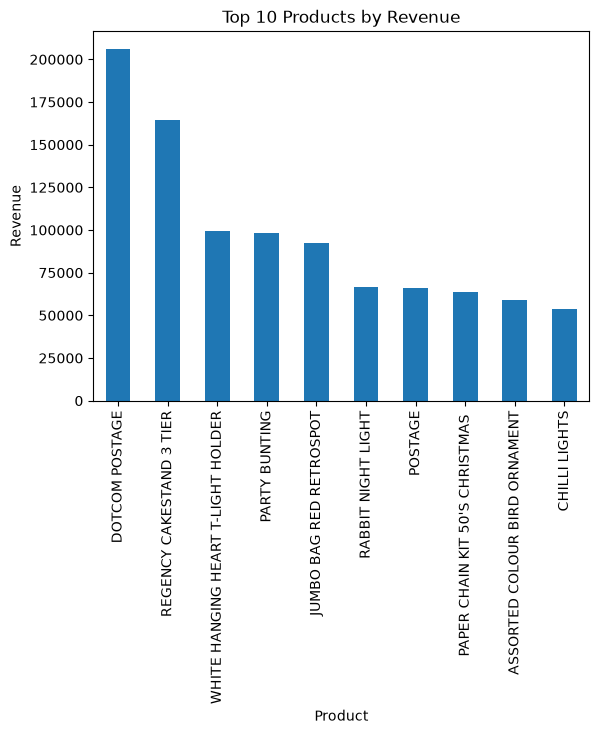

In [45]:
import matplotlib.pyplot as plt

top_products.plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')

plt.show()

In [46]:
#Top 10 products were identified based on total revenue generated. DOTCOM POSTAGE generated the highest revenue, followed by REGENCY CAKESTAND 3 TIER and WHITE HANGING HEART T-LIGHT HOLDER.
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

monthly_sales

Month
1      558448.560
2      497026.410
3      682013.980
4      492367.841
5      722094.100
6      689977.230
7      680156.991
8      681386.460
9     1017596.682
10    1069368.230
11    1456145.800
12    1179424.670
Name: Total_Sales, dtype: float64

In [47]:
df['Year'].value_counts()

Year
2011    493331
2010     41856
Name: count, dtype: int64

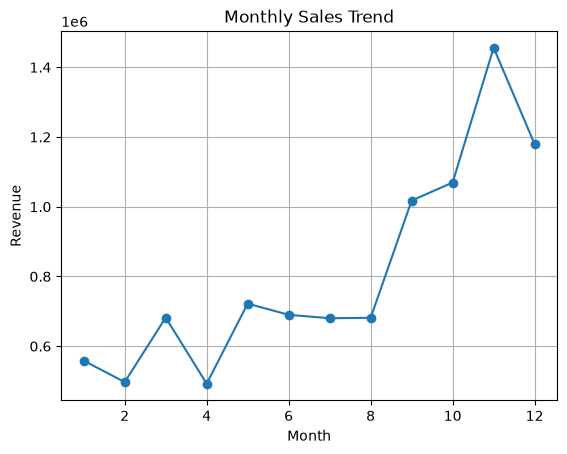

In [48]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)

plt.show()

In [49]:
#Monthly sales showed a steady growth throughout the year. Revenue peaked in November, indicating strong customer demand during the holiday season. Sales remained relatively lower during February and April.
country_sales = df.groupby('Country')['Total_Sales'].sum().sort_values(ascending=False).head(10)

country_sales

Country
United Kingdom    8167128.184
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Total_Sales, dtype: float64

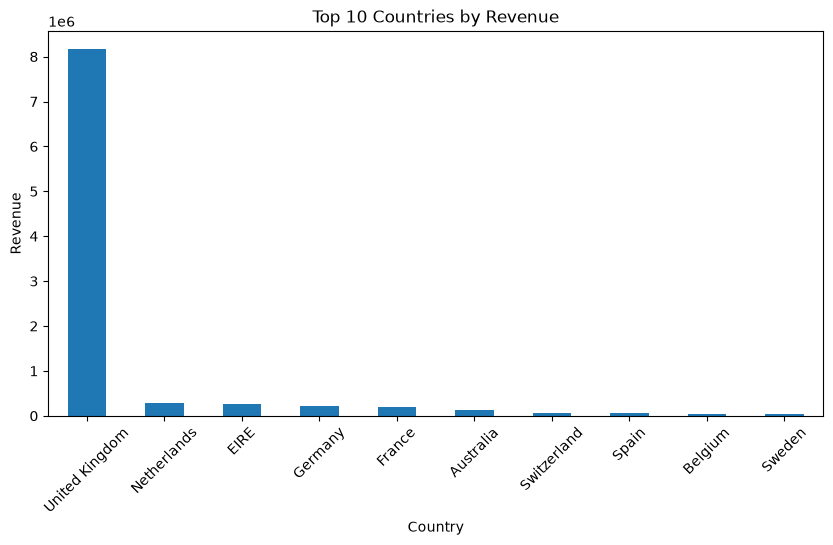

In [50]:
#Country-wise analysis revealed that the United Kingdom generated the highest revenue, contributing the majority of total sales. Netherlands and EIRE were the next highest-performing markets.
import matplotlib.pyplot as plt

country_sales.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

In [51]:
df.to_csv("cleaned_retail_sales.csv", index=False)

In [52]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Adobe Acrobat.lnk',
 'Adobe Express.lnk',
 'C',
 'C++',
 'Canva.lnk',
 'cleaned_retail_sales.csv',
 'desktop.ini',
 'draw.io.lnk',
 'Excel',
 'Free Icons PNG, ICO, ICNS and SVG.lnk',
 'Git Bash.lnk',
 'GitHub.lnk',
 'HackerRank.lnk',
 'Hotstar.lnk',
 'HTML',
 'iStudio.lnk',
 'Java',
 'Jupyter Notebook.lnk',
 'LinkedIn.lnk',
 'Microsoft Edge.lnk',
 'Notion.lnk',
 'online_retail.csv',
 'Pandas',
 'Python',
 'Retail-Sales-Analysis',
 'Retail_Sales_Analysis_Preparation.ipynb',
 'SSMS',
 'Telegram.lnk',
 'Visual Studio Code.lnk',
 'VLC media player.lnk']

In [53]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Sales,Month,Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010


In [54]:
df.shape

(535187, 11)

In [55]:
import os
os.path.exists("cleaned_retail_sales.csv")

True